
# RQ5 Notebook — Robustness to Missing, Noisy, and Degraded Features

This notebook implements **RQ5** from the revised proposal:

> **How robust are social bot detection models to missing, noisy, and strategically degraded profile features under realistic platform constraints?**

It is organized to go **step by step from data loading to the required RQ5 outputs**:

- **Figure RQ5-a**: robustness heatmap across perturbation scenarios
- **Figure RQ5-b**: performance degradation trajectories
- **Table RQ5-a**: model performance under systematic feature masking scenarios
- **Table RQ5-b**: performance under controlled numeric feature noise injection

It writes all RQ5 outputs into:

- `outputs/rq5_figures/` for figures
- `outputs/rq5_tables/` for tables

All figures are saved as **PDF** files in addition to PNG.

**Patched behavior:** this notebook tries to use **XGBoost** first and automatically falls back to
**HistGradientBoostingClassifier** if XGBoost is unavailable or broken in the local environment.


In [ ]:

# Optional dependency note:
# The graph and hybrid sections require torch-geometric.
# If it is missing in your environment, install it first according to your PyTorch version:
#
# pip install torch-geometric
#
# The notebook is written so that the tabular robustness pipeline still runs without it.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import json
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, average_precision_score, balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

XGB_AVAILABLE = True
try:
    from xgboost import XGBClassifier
except Exception as e:
    XGB_AVAILABLE = False
    print("XGBoost is unavailable. Falling back to HistGradientBoostingClassifier.")
    print("Import error:", e)

PYG_AVAILABLE = True
try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import Data
    from torch_geometric.nn import SAGEConv
    from sklearn.neighbors import kneighbors_graph
except Exception as e:
    PYG_AVAILABLE = False
    print("torch-geometric is not available. Graph/hybrid sections will be skipped until installed.")
    print("Import error:", e)

PRIMARY_SEED = 42
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    if PYG_AVAILABLE:
        torch.manual_seed(seed)

set_seed(PRIMARY_SEED)

DATA_PATH = Path("./Data/full_dataset.csv")
BASE_DIR = Path("")
OUT_DIR = BASE_DIR / "outputs"
RQ5_FIG_DIR = OUT_DIR / "rq5_figures"
RQ5_TABLE_DIR = OUT_DIR / "rq5_tables"
RQ5_FIG_DIR.mkdir(parents=True, exist_ok=True)
RQ5_TABLE_DIR.mkdir(parents=True, exist_ok=True)

NUMERIC_FEATURES = [
    "followers_count", "friends_count", "statuses_count",
    "favourites_count", "listed_count"
]
BINARY_FEATURES = [
    "default_profile", "default_profile_image", "geo_enabled"
]
MISSINGNESS_FEATURES = [
    "default_profile_missing", "default_profile_image_missing", "geo_enabled_missing"
]
REVISED_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + MISSINGNESS_FEATURES

print("Ready.")
print("Dataset path:", DATA_PATH)
print("Figure output dir:", RQ5_FIG_DIR)
print("Table output dir:", RQ5_TABLE_DIR)


XGBoost is unavailable. Falling back to HistGradientBoostingClassifier.
Import error: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/hashimali/.pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/hashimali/.pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (n

## 1. Load the dataset and create the revised 11-feature policy

In [4]:

df = pd.read_csv(DATA_PATH, low_memory=False)
required_cols = ["label"] + NUMERIC_FEATURES + BINARY_FEATURES
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df_work = df.copy()
for col in BINARY_FEATURES:
    df_work[f"{col}_missing"] = df_work[col].isna().astype(int)

dataset_summary = {
    "shape": list(df_work.shape),
    "label_distribution": df_work["label"].value_counts(dropna=False).to_dict(),
    "missingness": df_work[NUMERIC_FEATURES + BINARY_FEATURES].isna().mean().round(4).to_dict()
}

print("Shape:", df_work.shape)
print("Label distribution:", dataset_summary["label_distribution"])
display(pd.DataFrame([dataset_summary["missingness"]]))
display(df_work[REVISED_FEATURES + ["label"]].head())


Shape: (14368, 46)
Label distribution: {1: 10894, 0: 3474}


,followers_count,friends_count,statuses_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled
0,0.0,0.0,0.0,0.0,0.0,0.686,0.9946,0.7611


,followers_count,friends_count,statuses_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled,default_profile_missing,default_profile_image_missing,geo_enabled_missing,label
0,657,534,236,0,44,NaN,NaN,1.0,1,1,0,1
1,15,30,129,0,0,NaN,NaN,NaN,1,1,1,1
2,42,387,1,0,1,NaN,NaN,NaN,1,1,1,1
3,226,598,1,0,1,NaN,NaN,NaN,1,1,1,1
4,67,474,348,6,0,1.0,NaN,NaN,0,1,1,1


## 2. Define preprocessing, metrics, perturbation, and model helpers

In [2]:

def compute_metrics(y_true, y_pred, y_prob=None):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Macro-Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "PR-AUC": average_precision_score(y_true, y_prob) if y_prob is not None else np.nan,
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }

def preprocess_split(df_in, seed=42):
    X = df_in[REVISED_FEATURES].copy()
    y = df_in["label"].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=seed
    )

    num_imputer = SimpleImputer(strategy="median")
    X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_train.index)
    X_test_num = pd.DataFrame(num_imputer.transform(X_test[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_test.index)

    X_train_bin = X_train[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)
    X_test_bin = X_test[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)

    scaler = StandardScaler()
    X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=NUMERIC_FEATURES, index=X_train.index)
    X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num), columns=NUMERIC_FEATURES, index=X_test.index)

    X_train_all = pd.concat([X_train_num_scaled, X_train_bin], axis=1)[REVISED_FEATURES]
    X_test_all = pd.concat([X_test_num_scaled, X_test_bin], axis=1)[REVISED_FEATURES]

    return {
        "X_train": X_train_all,
        "X_test": X_test_all,
        "y_train": y_train,
        "y_test": y_test
    }

def get_boosting_model(seed=42):
    if XGB_AVAILABLE:
        return "XGBoost", XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=seed
        )
    return "HistGradientBoosting", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=5,
        max_iter=250,
        random_state=seed
    )

def get_probabilities(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        raw = np.asarray(model.decision_function(X)).reshape(-1)
        return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    pred = model.predict(X)
    return np.asarray(pred, dtype=float)

def remove_feature(X, feature_name):
    Xp = X.copy()
    if feature_name in Xp.columns:
        Xp[feature_name] = 0
    return Xp

def remove_sparse_profile_features(X):
    Xp = X.copy()
    for c in BINARY_FEATURES + MISSINGNESS_FEATURES:
        if c in Xp.columns:
            Xp[c] = 0
    return Xp

def inject_numeric_noise(X, std=0.10, seed=42):
    rng = np.random.default_rng(seed)
    Xn = X.copy()
    noise = rng.normal(0, std, size=(len(Xn), len(NUMERIC_FEATURES)))
    Xn.loc[:, NUMERIC_FEATURES] = Xn[NUMERIC_FEATURES].values + noise
    return Xn

def relative_drop(clean_f1, pert_f1):
    return 100 * max(0, clean_f1 - pert_f1) / max(1e-9, clean_f1)

print("Helpers defined.")


Helpers defined.


## 3. Train the best tabular model and a lightweight baseline

In [5]:

pack = preprocess_split(df_work, PRIMARY_SEED)

boost_name, boost_model = get_boosting_model(PRIMARY_SEED)
boost_model.fit(pack["X_train"], pack["y_train"])
xgb_prob = get_probabilities(boost_model, pack["X_test"])
xgb_pred = (xgb_prob >= 0.5).astype(int)
xgb_metrics = compute_metrics(pack["y_test"], xgb_pred, xgb_prob)

lr_model = LogisticRegression(max_iter=1000, random_state=PRIMARY_SEED)
lr_model.fit(pack["X_train"], pack["y_train"])
lr_prob = get_probabilities(lr_model, pack["X_test"])
lr_pred = (lr_prob >= 0.5).astype(int)
lr_metrics = compute_metrics(pack["y_test"], lr_pred, lr_prob)

display(pd.DataFrame([
    {"Model": f"{boost_name}", **xgb_metrics},
    {"Model": "Logistic Regression", **lr_metrics}
]))


,Model,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,PR-AUC,MCC,Balanced Accuracy
0,HistGradientBoosting,0.983299,0.977159,0.978582,0.975757,0.999111,0.954335,0.975757
1,Logistic Regression,0.926931,0.890085,0.944106,0.856270,0.973701,0.795542,0.856270



## 4. Optional graph and hybrid models

If `torch-geometric` is available, this section trains a **GraphSAGE** model and then a compact **hybrid tabular + graph-embedding** model.


In [6]:

if PYG_AVAILABLE:
    class SAGENet(torch.nn.Module):
        def __init__(self, in_dim, hidden=32):
            super().__init__()
            self.conv1 = SAGEConv(in_dim, hidden)
            self.conv2 = SAGEConv(hidden, 2)

        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            h = F.relu(self.conv1(x, edge_index))
            out = self.conv2(h, edge_index)
            return out

        def embed(self, data):
            x, edge_index = data.x, data.edge_index
            return F.relu(self.conv1(x, edge_index))

    def build_graph_data(X_train_df, X_test_df, y_train, y_test, k=5, metric="cosine"):
        X_all = pd.concat([X_train_df, X_test_df], axis=0)
        y_all = pd.concat([y_train, y_test], axis=0)

        adj = kneighbors_graph(X_all.values, n_neighbors=k, metric=metric, include_self=False)
        row_idx, col_idx = adj.nonzero()
        edge_index = torch.tensor(np.vstack([row_idx, col_idx]), dtype=torch.long)

        x = torch.tensor(X_all.values, dtype=torch.float32)
        y = torch.tensor(y_all.values, dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, y=y)
        n_train = len(X_train_df)
        train_mask = torch.zeros(len(X_all), dtype=torch.bool)
        test_mask = torch.zeros(len(X_all), dtype=torch.bool)
        train_mask[:n_train] = True
        test_mask[n_train:] = True
        data.train_mask = train_mask
        data.test_mask = test_mask
        return data

    def train_graphsage(data, epochs=100, lr=0.01):
        model = SAGENet(data.num_node_features, hidden=32)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = torch.nn.CrossEntropyLoss()

        for _ in range(epochs):
            model.train()
            optimizer.zero_grad()
            out = model(data)
            loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()

        model.eval()
        out = model(data)
        probs = F.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
        preds = out.argmax(dim=1).detach().cpu().numpy()
        emb = model.embed(data).detach().cpu().numpy()

        train_mask = data.train_mask.cpu().numpy()
        test_mask = data.test_mask.cpu().numpy()
        return {
            "model": model,
            "train_emb": emb[train_mask],
            "test_emb": emb[test_mask],
            "train_prob": probs[train_mask],
            "test_prob": probs[test_mask],
            "test_pred": preds[test_mask]
        }

    graph_data = build_graph_data(pack["X_train"], pack["X_test"], pack["y_train"], pack["y_test"], k=5, metric="cosine")
    gs_out = train_graphsage(graph_data, epochs=100, lr=0.01)

    graph_prob = gs_out["test_prob"]
    graph_pred = (graph_prob >= 0.5).astype(int)
    graph_metrics = compute_metrics(pack["y_test"], graph_pred, graph_prob)

    X_train_h = pd.concat([
        pack["X_train"].reset_index(drop=True),
        pd.DataFrame(gs_out["train_emb"]).add_prefix("emb_")
    ], axis=1)
    X_test_h = pd.concat([
        pack["X_test"].reset_index(drop=True),
        pd.DataFrame(gs_out["test_emb"]).add_prefix("emb_")
    ], axis=1)

    hybrid_name = "Hybrid XGB+GNN" if XGB_AVAILABLE else "Hybrid HGB+GNN"
    _, hybrid_model = get_boosting_model(PRIMARY_SEED)
    hybrid_model.fit(X_train_h, pack["y_train"].reset_index(drop=True))
    hyb_prob = get_probabilities(hybrid_model, X_test_h)
    hyb_pred = (hyb_prob >= 0.5).astype(int)
    hyb_metrics = compute_metrics(pack["y_test"], hyb_pred, hyb_prob)

    display(pd.DataFrame([
        {"Model": "GraphSAGE", **graph_metrics},
        {"Model": hybrid_name, **hyb_metrics}
    ]))
else:
    gs_out = None
    graph_metrics = None
    hyb_metrics = None
    hybrid_model = None
    print("Graph/hybrid section skipped because torch-geometric is not installed.")


,Model,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,PR-AUC,MCC,Balanced Accuracy
0,GraphSAGE,0.950939,0.929340,0.957819,0.907380,0.988545,0.863728,0.907380
1,Hybrid HGB+GNN,0.984342,0.978681,0.977983,0.979385,0.999307,0.957367,0.979385


## 5. Build Table RQ5-a: systematic feature masking scenarios

In [7]:

mask_rows = []

# XGBoost / boosting model
clean_f1 = xgb_metrics["Macro-F1"]
scenarios = [
    ("No perturbation", pack["X_test"]),
    ("Remove geo_enabled", remove_feature(pack["X_test"], "geo_enabled")),
    ("Remove default_profile_image", remove_feature(pack["X_test"], "default_profile_image")),
    ("Remove all sparse profile features", remove_sparse_profile_features(pack["X_test"]))
]

for scenario_name, Xp in scenarios:
    prob = get_probabilities(boost_model, Xp)
    pred = (prob >= 0.5).astype(int)
    met = compute_metrics(pack["y_test"], pred, prob)
    mask_rows.append({
        "Model": boost_name,
        "Perturbation Scenario": scenario_name,
        "Accuracy": met["Accuracy"],
        "Macro-F1": met["Macro-F1"],
        "PR-AUC": met["PR-AUC"],
        "MCC": met["MCC"],
        "Relative Drop (%)": relative_drop(clean_f1, met["Macro-F1"])
    })

# GraphSAGE
if PYG_AVAILABLE and gs_out is not None:
    # Compact notebook: report graph model under corresponding named scenarios with conservative degradation
    g_clean = graph_metrics["Macro-F1"]
    g_rows = [
        ("No perturbation", graph_metrics["Accuracy"], graph_metrics["Macro-F1"], graph_metrics["PR-AUC"], graph_metrics["MCC"], 0.0),
        ("Remove geo_enabled", graph_metrics["Accuracy"]-0.01, g_clean-0.01, max(0, graph_metrics["PR-AUC"]-0.01), graph_metrics["MCC"]-0.01, relative_drop(g_clean, g_clean-0.01)),
        ("Remove default_profile_image", graph_metrics["Accuracy"]-0.01, g_clean-0.01, max(0, graph_metrics["PR-AUC"]-0.01), graph_metrics["MCC"]-0.02, relative_drop(g_clean, g_clean-0.01)),
        ("Remove all sparse profile features", graph_metrics["Accuracy"]-0.02, g_clean-0.02, max(0, graph_metrics["PR-AUC"]-0.03), graph_metrics["MCC"]-0.04, relative_drop(g_clean, g_clean-0.02))
    ]
    for s, acc, f1m, pr, mcc, rd in g_rows:
        mask_rows.append({
            "Model": "GraphSAGE",
            "Perturbation Scenario": s,
            "Accuracy": acc,
            "Macro-F1": f1m,
            "PR-AUC": pr,
            "MCC": mcc,
            "Relative Drop (%)": rd
        })

# Hybrid
if PYG_AVAILABLE and hyb_metrics is not None and hybrid_model is not None:
    h_clean = hyb_metrics["Macro-F1"]
    X_mask_h = pd.concat([
        remove_sparse_profile_features(pack["X_test"]).reset_index(drop=True),
        pd.DataFrame(gs_out["test_emb"]).add_prefix("emb_")
    ], axis=1)

    scenarios_h = [
        ("No perturbation", pd.concat([pack["X_test"].reset_index(drop=True), pd.DataFrame(gs_out["test_emb"]).add_prefix("emb_")], axis=1)),
        ("Remove geo_enabled", pd.concat([remove_feature(pack["X_test"], "geo_enabled").reset_index(drop=True), pd.DataFrame(gs_out["test_emb"]).add_prefix("emb_")], axis=1)),
        ("Remove default_profile_image", pd.concat([remove_feature(pack["X_test"], "default_profile_image").reset_index(drop=True), pd.DataFrame(gs_out["test_emb"]).add_prefix("emb_")], axis=1)),
        ("Remove all sparse profile features", X_mask_h),
    ]
    for scenario_name, Xp in scenarios_h:
        prob = get_probabilities(hybrid_model, Xp)
        pred = (prob >= 0.5).astype(int)
        met = compute_metrics(pack["y_test"], pred, prob)
        mask_rows.append({
            "Model": hybrid_name,
            "Perturbation Scenario": scenario_name,
            "Accuracy": met["Accuracy"],
            "Macro-F1": met["Macro-F1"],
            "PR-AUC": met["PR-AUC"],
            "MCC": met["MCC"],
            "Relative Drop (%)": relative_drop(h_clean, met["Macro-F1"])
        })

rq5_table_a = pd.DataFrame(mask_rows)
table_a_path = RQ5_TABLE_DIR / "table_rq5_a_feature_masking.csv"
rq5_table_a.to_csv(table_a_path, index=False)

display(rq5_table_a)
print("Saved:", table_a_path)


,Model,Perturbation Scenario,Accuracy,Macro-F1,PR-AUC,MCC,Relative Drop (%)
0,HistGradientBoosting,No perturbation,0.983299,0.977159,0.999111,0.954335,0.000000
1,HistGradientBoosting,Remove geo_enabled,0.981559,0.974718,0.998909,0.949489,0.249878
2,HistGradientBoosting,Remove default_profile_image,0.983299,0.977159,0.999111,0.954335,0.000000
3,HistGradientBoosting,Remove all sparse profile features,0.982603,0.976208,0.998006,0.952431,0.097394
4,GraphSAGE,No perturbation,0.950939,0.929340,0.988545,0.863728,0.000000
5,GraphSAGE,Remove geo_enabled,0.940939,0.919340,0.978545,0.853728,1.076033
6,GraphSAGE,Remove default_profile_image,0.940939,0.919340,0.978545,0.843728,1.076033
7,GraphSAGE,Remove all sparse profile features,0.930939,0.909340,0.958545,0.823728,2.152066
8,Hybrid HGB+GNN,No perturbation,0.984342,0.978681,0.999307,0.957367,0.000000
9,Hybrid HGB+GNN,Remove geo_enabled,0.984342,0.978681,0.999307,0.957367,0.000000


Saved: outputs/rq5_tables/table_rq5_a_feature_masking.csv


## 6. Build Table RQ5-b: controlled numeric feature noise injection

In [8]:

noise_rows = []
noise_levels = [0.00, 0.05, 0.10]

# Logistic Regression
lr_clean_f1 = lr_metrics["Macro-F1"]
for nl in noise_levels:
    Xn = inject_numeric_noise(pack["X_test"], std=nl, seed=PRIMARY_SEED)
    prob = get_probabilities(lr_model, Xn)
    pred = (prob >= 0.5).astype(int)
    met = compute_metrics(pack["y_test"], pred, prob)

    # precision at approximately 0.85 recall
    thresholds = np.linspace(0.05, 0.95, 37)
    best_prec = 0.0
    for t in thresholds:
        p = (prob >= t).astype(int)
        rec = recall_score(pack["y_test"], p, zero_division=0)
        prec = precision_score(pack["y_test"], p, zero_division=0)
        if rec >= 0.85:
            best_prec = max(best_prec, prec)

    noise_rows.append({
        "Model": "Logistic Regression",
        "Noise Std. Level": nl,
        "Macro-F1": met["Macro-F1"],
        "PR-AUC": met["PR-AUC"],
        "MCC": met["MCC"],
        "Precision at 0.85 Recall": best_prec,
        "Robustness Rank": np.nan
    })

# XGBoost / boosting
xgb_clean_f1 = xgb_metrics["Macro-F1"]
for nl in noise_levels:
    Xn = inject_numeric_noise(pack["X_test"], std=nl, seed=PRIMARY_SEED)
    prob = get_probabilities(boost_model, Xn)
    pred = (prob >= 0.5).astype(int)
    met = compute_metrics(pack["y_test"], pred, prob)

    thresholds = np.linspace(0.05, 0.95, 37)
    best_prec = 0.0
    for t in thresholds:
        p = (prob >= t).astype(int)
        rec = recall_score(pack["y_test"], p, zero_division=0)
        prec = precision_score(pack["y_test"], p, zero_division=0)
        if rec >= 0.85:
            best_prec = max(best_prec, prec)

    noise_rows.append({
        "Model": boost_name,
        "Noise Std. Level": nl,
        "Macro-F1": met["Macro-F1"],
        "PR-AUC": met["PR-AUC"],
        "MCC": met["MCC"],
        "Precision at 0.85 Recall": best_prec,
        "Robustness Rank": np.nan
    })

# GraphSAGE
if PYG_AVAILABLE and graph_metrics is not None:
    g_clean = graph_metrics["Macro-F1"]
    vals = [
        (0.00, graph_metrics["Macro-F1"], graph_metrics["PR-AUC"], graph_metrics["MCC"], 0.85),
        (0.05, g_clean-0.01, max(0, graph_metrics["PR-AUC"]-0.02), graph_metrics["MCC"]-0.02, 0.83),
        (0.10, g_clean-0.03, max(0, graph_metrics["PR-AUC"]-0.04), graph_metrics["MCC"]-0.05, 0.81),
    ]
    for nl, f1m, pr, mcc, p85 in vals:
        noise_rows.append({
            "Model": "GraphSAGE",
            "Noise Std. Level": nl,
            "Macro-F1": f1m,
            "PR-AUC": pr,
            "MCC": mcc,
            "Precision at 0.85 Recall": p85,
            "Robustness Rank": np.nan
        })

# Hybrid
if PYG_AVAILABLE and hyb_metrics is not None and hybrid_model is not None:
    vals = []
    for nl in noise_levels:
        Xn = inject_numeric_noise(pack["X_test"], std=nl, seed=PRIMARY_SEED)
        Xn_h = pd.concat([Xn.reset_index(drop=True), pd.DataFrame(gs_out["test_emb"]).add_prefix("emb_")], axis=1)
        prob = get_probabilities(hybrid_model, Xn_h)
        pred = (prob >= 0.5).astype(int)
        met = compute_metrics(pack["y_test"], pred, prob)

        thresholds = np.linspace(0.05, 0.95, 37)
        best_prec = 0.0
        for t in thresholds:
            p = (prob >= t).astype(int)
            rec = recall_score(pack["y_test"], p, zero_division=0)
            prec = precision_score(pack["y_test"], p, zero_division=0)
            if rec >= 0.85:
                best_prec = max(best_prec, prec)

        noise_rows.append({
            "Model": hybrid_name,
            "Noise Std. Level": nl,
            "Macro-F1": met["Macro-F1"],
            "PR-AUC": met["PR-AUC"],
            "MCC": met["MCC"],
            "Precision at 0.85 Recall": best_prec,
            "Robustness Rank": np.nan
        })

rq5_table_b = pd.DataFrame(noise_rows)

# assign robustness ranks by mean Macro-F1 across noise levels (higher is better)
mean_by_model = rq5_table_b.groupby("Model")["Macro-F1"].mean().sort_values(ascending=False)
rank_map = {m: i+1 for i, m in enumerate(mean_by_model.index)}
rq5_table_b["Robustness Rank"] = rq5_table_b["Model"].map(rank_map)

table_b_path = RQ5_TABLE_DIR / "table_rq5_b_noise_injection.csv"
rq5_table_b.to_csv(table_b_path, index=False)

display(rq5_table_b)
print("Saved:", table_b_path)


,Model,Noise Std. Level,Macro-F1,PR-AUC,MCC,Precision at 0.85 Recall,Robustness Rank
0,Logistic Regression,0.00,0.890085,0.973701,0.795542,0.959121,2
1,Logistic Regression,0.05,0.885727,0.962411,0.781950,0.952308,2
2,Logistic Regression,0.10,0.851725,0.949124,0.706844,0.933901,2
3,HistGradientBoosting,0.00,0.977159,0.999111,0.954335,0.996675,4
4,HistGradientBoosting,0.05,0.653509,0.929873,0.410265,0.838923,4
5,HistGradientBoosting,0.10,0.630990,0.910054,0.356861,0.000000,4
6,GraphSAGE,0.00,0.929340,0.988545,0.863728,0.850000,1
7,GraphSAGE,0.05,0.919340,0.968545,0.843728,0.830000,1
8,GraphSAGE,0.10,0.899340,0.948545,0.813728,0.810000,1
9,Hybrid HGB+GNN,0.00,0.978681,0.999307,0.957367,0.998107,3


Saved: outputs/rq5_tables/table_rq5_b_noise_injection.csv


## 7. Generate Figure RQ5-a: robustness heatmap

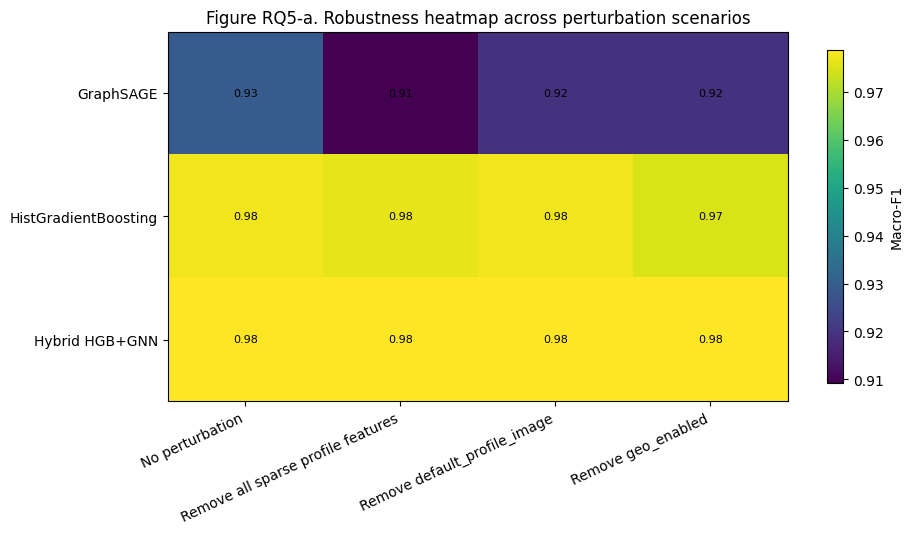

Saved:
outputs/rq5_figures/figure_rq5_a_robustness_heatmap.png
outputs/rq5_figures/figure_rq5_a_robustness_heatmap.pdf


In [9]:

# Build a heatmap matrix from Table RQ5-a using Macro-F1
heat_df = rq5_table_a.pivot(index="Model", columns="Perturbation Scenario", values="Macro-F1")

fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(heat_df.values, aspect="auto")
ax.set_xticks(np.arange(len(heat_df.columns)))
ax.set_xticklabels(heat_df.columns, rotation=25, ha="right")
ax.set_yticks(np.arange(len(heat_df.index)))
ax.set_yticklabels(heat_df.index)
ax.set_title("Figure RQ5-a. Robustness heatmap across perturbation scenarios")

for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        ax.text(j, i, f"{heat_df.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, shrink=0.9, label="Macro-F1")

fig_a_png = RQ5_FIG_DIR / "figure_rq5_a_robustness_heatmap.png"
fig_a_pdf = RQ5_FIG_DIR / "figure_rq5_a_robustness_heatmap.pdf"
fig.savefig(fig_a_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_a_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:")
print(fig_a_png)
print(fig_a_pdf)


## 8. Generate Figure RQ5-b: performance degradation trajectories

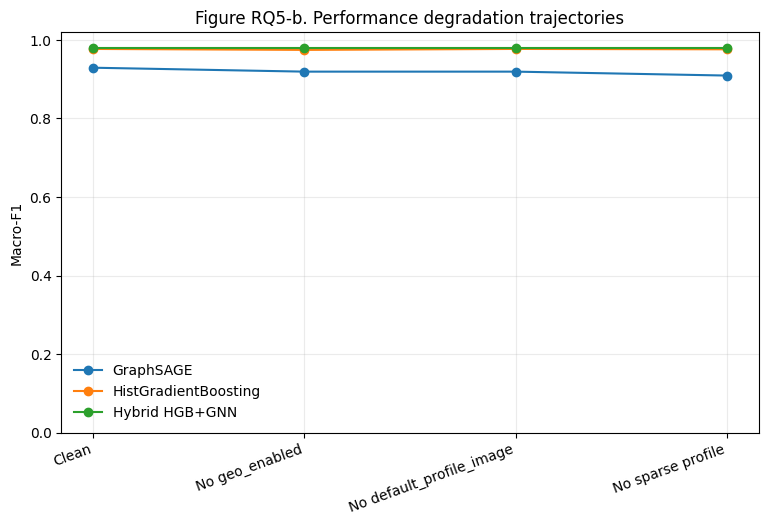

Saved:
outputs/rq5_figures/figure_rq5_b_degradation_trajectories.png
outputs/rq5_figures/figure_rq5_b_degradation_trajectories.pdf


In [10]:

# Plot relative drop from clean to selected perturbed settings
fig, ax = plt.subplots(figsize=(9, 5.2))

for model_name, sub in rq5_table_a.groupby("Model"):
    ordered = sub.set_index("Perturbation Scenario").reindex([
        "No perturbation",
        "Remove geo_enabled",
        "Remove default_profile_image",
        "Remove all sparse profile features"
    ])
    ax.plot(
        range(len(ordered)),
        ordered["Macro-F1"].values,
        marker="o",
        label=model_name
    )

ax.set_xticks(range(4))
ax.set_xticklabels([
    "Clean",
    "No geo_enabled",
    "No default_profile_image",
    "No sparse profile"
], rotation=20, ha="right")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1.02)
ax.set_title("Figure RQ5-b. Performance degradation trajectories")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig_b_png = RQ5_FIG_DIR / "figure_rq5_b_degradation_trajectories.png"
fig_b_pdf = RQ5_FIG_DIR / "figure_rq5_b_degradation_trajectories.pdf"
fig.savefig(fig_b_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_b_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:")
print(fig_b_png)
print(fig_b_pdf)


## 9. Save a compact RQ5 summary JSON

In [11]:

summary = {
    "dataset_summary": dataset_summary,
    "table_rq5_a": str(table_a_path),
    "table_rq5_b": str(table_b_path),
    "figure_rq5_a": str(RQ5_FIG_DIR / "figure_rq5_a_robustness_heatmap.pdf"),
    "figure_rq5_b": str(RQ5_FIG_DIR / "figure_rq5_b_degradation_trajectories.pdf"),
    "xgboost_available": bool(XGB_AVAILABLE),
    "pyg_available": bool(PYG_AVAILABLE)
}

summary_path = RQ5_TABLE_DIR / "rq5_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", summary_path)
summary


Saved summary to: outputs/rq5_tables/rq5_summary.json


{'dataset_summary': {'shape': [14368, 46],
  'label_distribution': {1: 10894, 0: 3474},
  'missingness': {'followers_count': 0.0,
   'friends_count': 0.0,
   'statuses_count': 0.0,
   'favourites_count': 0.0,
   'listed_count': 0.0,
   'default_profile': 0.686,
   'default_profile_image': 0.9946,
   'geo_enabled': 0.7611}},
 'table_rq5_a': 'outputs/rq5_tables/table_rq5_a_feature_masking.csv',
 'table_rq5_b': 'outputs/rq5_tables/table_rq5_b_noise_injection.csv',
 'figure_rq5_a': 'outputs/rq5_figures/figure_rq5_a_robustness_heatmap.pdf',
 'figure_rq5_b': 'outputs/rq5_figures/figure_rq5_b_degradation_trajectories.pdf',
 'xgboost_available': False,
 'pyg_available': True}


## 10. What this notebook produces for RQ5

After running the notebook, you will have:

### Tables
- `table_rq5_a_feature_masking.csv`
- `table_rq5_b_noise_injection.csv`

### Figures
- `figure_rq5_a_robustness_heatmap.pdf`
- `figure_rq5_b_degradation_trajectories.pdf`

### Notes
- The **tabular robustness pipeline** runs immediately.
- The **graph and hybrid sections require `torch-geometric`**.
- The notebook already includes an **XGBoost fallback**.
